Device: cuda
Converted pheno_onehot to np.float32 for 0 nodes.
Nodes — train: 1246 | val: 415 | test: 417
Converted pheno_onehot to np.float32 for 0 nodes.
Training Node2Vec embeddings


Training Node2Vec:   0%|          | 0/500 [00:00<?, ?epoch/s]

tensor([24.8521, 31.7714, 52.2148,  2.7759, 80.8898], device='cuda:0')


Training:   0%|          | 0/2000 [00:00<?, ?epoch/s]


Early stopping at epoch 530 — best val loss: 4.9987


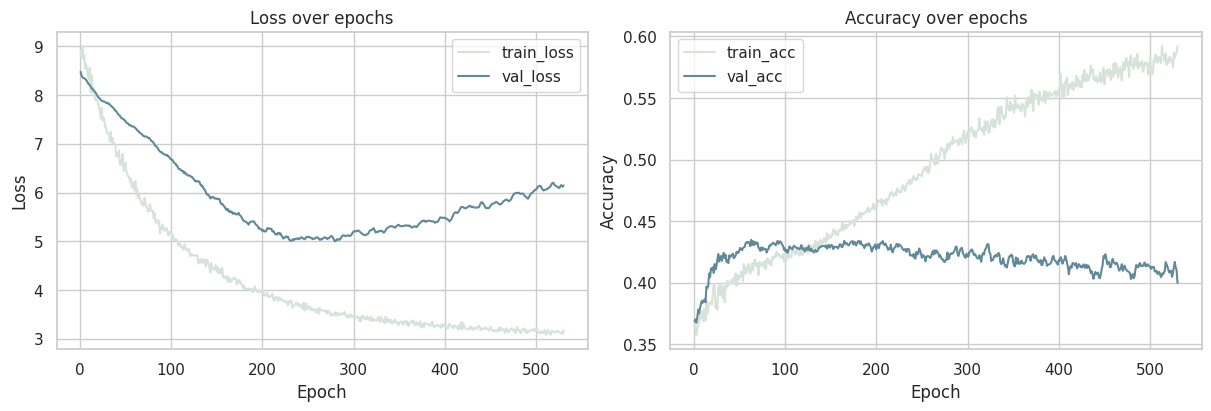

Final epoch - Train acc: 0.5921, Val acc: 0.3998
Best val acc: 0.3998
Restored best model — val loss: 4.9987


,Hamming Loss,Exact Match,Micro F1,Macro F1,Sample F1,Jaccard
Model,,,,,,
Model,0.5947,0.0264,0.3969,0.3972,0.3923,0.2793


,accuracy,f1_micro,f1_macro,precision,recall,support_pos
CAD,0.4101,0.3627,0.4068,0.8333,0.2318,302
CKD,0.2926,0.4135,0.2611,0.9811,0.2620,397
DMT2,0.4556,0.3641,0.4441,0.8228,0.2338,278
Healthy,0.5803,0.5478,0.5782,0.5889,0.5121,207
OST,0.2878,0.2979,0.2876,0.8400,0.1810,348


Embeddings: (2078, 32)
Splits: 1246 415 417
Saved: /work/gr-fe/bryan/MOGSage/results/SHCS//mogsage_gnn_embeddings_0.2.pkl
Saved model: /work/gr-fe/bryan/MOGSage/results/SHCS//mogsage_gnn_model.pth


In [2]:
# ============================================================
# CONFIG
# ============================================================
DATADIR       = "/work/gr-fe/bryan/data/SHCS/"
OUTDIR        = "/work/gr-fe/bryan/MOGSage/results/SHCS/"
GPREFIX       = "KGshcs"
ATTRS_TO_KEEP = {'pheno_onehot'}
SEED          = 7
CLASS_LABELS  = ['CAD','CKD','DMT2','Healthy','OST']
OMICS         = ['Proteomics' , 'Metabolomics' , 'PGS']

# Split
TRAIN_FRAC    = 0.6
VAL_FRAC      = 0.2

# Model
HIDDEN_DIM = 64
EMB_DIM = 32
ENC_DIMS = [64,64,32]
LATENT_DIMS = [32,32,12]
DECODER_DIM = 64
GNN_DIMS = [HIDDEN_DIM,EMB_DIM] 
DROPOUT       = 0.5

# Loaders
TRAIN_BATCH   = 1024
VAL_BATCH     = 1024
NUM_NEIGHBORS = [15, 10]

# Contrastive 
ALPHA_CONTRAST = 0.2
TEMPERATURE = 0.07

# Optimiser
LR            = 5e-4
WEIGHT_DECAY  = 1e-4

# Training
EPOCHS        = 2000
ES_PATIENCE   = 250
ES_MIN_DELTA  = 1e-6
THRESHOLD     = 0.5

# Outputs
GEN_EMB = True
SAVE_MODEL = True

# ============================================================
# IMPORTS
# ============================================================
import os, sys, pickle
import numpy as np
import pandas as pd
from functools import reduce

import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
from torch_geometric.nn import Node2Vec
from torch_geometric.utils import from_networkx
from torch_geometric.loader import NeighborLoader

sys.path.insert(0, '../MAIN/')
from helpers import (
            merge_dfs, 
            get_split_indices_from_masks, 
            extract_node_embeddings_fullgraph, 
            save_gnn_embeddings_pickle, 
            save_pytorch_model,
            median_impute_per_column,
)
from network_functions import fix_pheno_onehot_in_graph, nx_to_pyg, load_graph, node_labels, edge_index_weighted_resample
from train import evaluate_multilabel, training_metric_plots, contrastive_distill_loss, per_class_metrics_from_scores
from gnn import EarlyStopping, GraphSageSimple, MOGSage
from sklearn.preprocessing import StandardScaler

# Device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

# ============================================================
# 1) LOAD GRAPH
# ============================================================
g = load_graph(os.path.join(DATADIR, "Networks", f"{GPREFIX}_psn.gpickle"), "PSN")
cnt = fix_pheno_onehot_in_graph(g)
print(f"Converted pheno_onehot to np.float32 for {cnt} nodes.")

ei, order, weight = nx_to_pyg(g, ATTRS_TO_KEEP, get_weight=True)
all_nodes = sorted(set(g.nodes))

# ============================================================
# 2) LOAD FEATURES
# ============================================================
expr_dfs = []
for expr in OMICS : 
    with open(os.path.join(DATADIR, "02_processed", f"{expr}.processed.pkl"), "rb") as f:
        data_expr = pickle.load(f)
    expr_df = data_expr["expr"]
    
    expr_dfs.append(expr_df.loc[expr_df.index.intersection(all_nodes)].copy())

meta    = node_labels(g)
meta    = pd.DataFrame(np.float32(meta.values), index=meta.index)
h_df    = reduce(merge_dfs, expr_dfs).reindex(all_nodes)
meta_df = meta.reindex(all_nodes)

x = torch.tensor(h_df.values,    dtype=torch.float32)
x = median_impute_per_column(x)

y = torch.tensor(meta_df.values, dtype=torch.float32)

INPUT_DIMS = [x.shape[1] for x in expr_dfs]

# ============================================================
# 3) PyG DATA + MASKS
# ============================================================
data   = from_networkx(g)
data.y = y

N       = len(all_nodes)
gen     = torch.Generator().manual_seed(SEED)
perm    = torch.randperm(N, generator=gen)
n_train = int(TRAIN_FRAC * N)
n_val   = int(VAL_FRAC   * N)

data.train_mask = torch.zeros(N, dtype=torch.bool)
data.val_mask   = torch.zeros(N, dtype=torch.bool)
data.test_mask  = torch.zeros(N, dtype=torch.bool)
data.train_mask[perm[:n_train]]                    = True
data.val_mask  [perm[n_train:n_train + n_val]]     = True
data.test_mask [perm[n_train + n_val:]]            = True

scaler = StandardScaler()
scaler.fit(x[perm[:n_train]])
data.x = torch.tensor(scaler.transform(x), dtype=torch.float32)

print(f"Nodes — train: {data.train_mask.sum()} | val: {data.val_mask.sum()} | test: {data.test_mask.sum()}")

# ============================================================
# 4) LOADERS
# ============================================================
_loader_kwargs = dict(num_neighbors=NUM_NEIGHBORS, persistent_workers=False)

train_loader = NeighborLoader(data, input_nodes=data.train_mask, batch_size=TRAIN_BATCH, shuffle=True,  **_loader_kwargs)
val_loader   = NeighborLoader(data, input_nodes=data.val_mask,   batch_size=VAL_BATCH,   shuffle=False, **_loader_kwargs)
test_loader  = NeighborLoader(data, input_nodes=data.test_mask,  batch_size=VAL_BATCH,   shuffle=False, **_loader_kwargs)

# ============================================================
# 5) TRAIN TEACHER ONLY MODEL
# ============================================================
# ── Node2Vec teacher ──────────────────────
kg = load_graph(os.path.join(DATADIR, "Networks", f"{GPREFIX}.gpickle"), "PSN")
cnt = fix_pheno_onehot_in_graph(kg)
print(f"Converted pheno_onehot to np.float32 for {cnt} nodes.")

ei, order, weight = nx_to_pyg(kg, ATTRS_TO_KEEP, get_weight=True)
teacher_data = from_networkx(kg)
edge_index_w = edge_index_weighted_resample(
    teacher_data.edge_index,
    teacher_data.weight,
    num_samples=teacher_data.edge_index.size(1)
).to(device)

# ── Node2Vec ─────────────────────────────────────────────────────────────────
node2vec = Node2Vec(
    edge_index=edge_index_w,
    embedding_dim=EMB_DIM,   
    walk_length=20,
    context_size=10,
    walks_per_node=10,
    num_negative_samples=1,
    p=1.0,
    q=1.0,
    sparse=True,
).to(device)

n2v_loader = node2vec.loader(batch_size=TRAIN_BATCH, shuffle=True, num_workers=0)
n2v_optim  = torch.optim.SparseAdam(node2vec.parameters(), lr=1e-3)

print("Training Node2Vec embeddings")
pbar = tqdm(range(500), desc="Training Node2Vec", unit="epoch")

for epoch in pbar:
    node2vec.train()
    total_loss = 0.0

    for pos_rw, neg_rw in n2v_loader:
        n2v_optim.zero_grad(set_to_none=True)
        loss = node2vec.loss(pos_rw.to(device), neg_rw.to(device))
        loss.backward()
        n2v_optim.step()
        total_loss += float(loss.detach().cpu())

    pbar.set_postfix(avg_loss=f"{total_loss / max(len(n2v_loader), 1):.4f}")

# ── Use embeddings directly as teacher_logits ─────────────────────────────────
node2vec.eval()
with torch.no_grad():
    teacher_logits = node2vec()  # (num_teacher_nodes, y.shape[1])

data.teacher_logits = teacher_logits

# ============================================================
# 5) MODEL, OPTIMISER, EARLY STOPPING
# ============================================================

model = MOGSage(input_dims=INPUT_DIMS, 
                encoder_dims=ENC_DIMS, 
                latent_dims=LATENT_DIMS,
                decoder_dim=DECODER_DIM,
                hidden_dims=GNN_DIMS, 
                num_classes=y.shape[1], 
                dropout=DROPOUT).to(device)

optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
es    = EarlyStopping(patience=ES_PATIENCE, min_delta=ES_MIN_DELTA)

with torch.no_grad():
    pos        = y[perm[:n_train]].sum(dim=0)
    neg        = y[perm[:n_train]].shape[0] - pos
    pos_weight = ((neg / (pos + 1e-8))**3).clamp(1,100).to(device)
    print(pos_weight)

criterion_node = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

# ============================================================
# 7) TRAINING LOOP
# ============================================================
history = {"epoch": [], "train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
pbar    = tqdm(range(1, EPOCHS + 1), desc="Training", unit="epoch")

for epoch in pbar:
    # ---- train ----
    model.train()
    total_loss, total_seeds = 0.0, 0
    tr_tp = tr_fp = tr_fn = 0.0  # for train micro-F1

    for batch in train_loader:
        batch      = batch.to(device)
        seed_count = batch.batch_size

        optim.zero_grad(set_to_none=True)
        h_seed, logits = model(batch.x, batch.edge_index)

        logits = logits[:seed_count]
        h_seed = h_seed[:seed_count]
        h_t_seed = data.teacher_logits[batch.n_id[:seed_count]].to(device)
        y_seed = batch.y[:seed_count]
        
        bce = criterion_node(logits,y_seed)
        mse = contrastive_distill_loss(h_seed, h_t_seed, temperature=TEMPERATURE)

        loss = bce + (ALPHA_CONTRAST*mse)
        
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optim.step()

        total_loss  += float(loss.detach().cpu()) * seed_count
        total_seeds += seed_count

        with torch.no_grad():
            y_pred = (torch.sigmoid(logits[:seed_count]) >= THRESHOLD).to(torch.int32)
            y_true = batch.y[:seed_count].to(torch.int32)
            tr_tp += float((y_pred &  y_true      ).sum())
            tr_fp += float((y_pred & (1 - y_true) ).sum())
            tr_fn += float(((1 - y_pred) & y_true ).sum())

    train_loss    = total_loss / max(total_seeds, 1)
    train_micro_f1 = (2 * tr_tp) / (2 * tr_tp + tr_fp + tr_fn + 1e-8)

    # ---- val ----
    model.eval()
    tp = fp = fn = 0.0
    val_total_loss, val_total_seeds = 0.0, 0

    with torch.no_grad():
        for batch in val_loader:
            batch      = batch.to(device)
            seed_count = batch.batch_size
            h_seed, logits = model(batch.x, batch.edge_index)
    
            logits = logits[:seed_count]
            h_seed = h_seed[:seed_count]
            h_t_seed = data.teacher_logits[batch.n_id[:seed_count]].to(device)
            y_true   = batch.y[:seed_count]

            val_bce_batch = criterion_node(logits, y_true)
            val_dis_batch = contrastive_distill_loss(h_seed, h_t_seed, temperature=TEMPERATURE)
            val_loss_batch = val_bce_batch + ALPHA_CONTRAST*val_dis_batch
            
            val_total_loss  += float(val_loss_batch) * seed_count
            val_total_seeds += seed_count

            y_pred = (torch.sigmoid(logits) >= THRESHOLD).to(torch.int32)
            y_true = y_true.to(torch.int32)

            tp += float((y_pred &  y_true          ).sum())
            fp += float((y_pred & (1 - y_true)     ).sum())
            fn += float(((1 - y_pred) &  y_true    ).sum())

    micro_f1 = (2 * tp) / (2 * tp + fp + fn + 1e-8)
    val_loss = val_total_loss / max(val_total_seeds, 1)

    history["epoch"].append(epoch)
    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_micro_f1)   
    history["val_loss"].append(val_loss)           
    history["val_acc"].append(micro_f1)

    pbar.set_postfix({
        "val_loss": f"{val_loss:.4f}",
        "val_F1":     f"{micro_f1:.4f}",
        "es_counter": f"{es.counter}/{es.patience}",
    })

    es.step(val_loss, model)
    if es.stop:
        print(f"\nEarly stopping at epoch {epoch} — best val loss: {es.best_score:.4f}")
        break

training_metric_plots(history, micro_f1)
es.restore(model)
print(f"Restored best model — val loss: {es.best_score:.4f}")

# ============================================================
# 8) TEST EVALUATION
# ============================================================
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        batch      = batch.to(device)
        seed_count = batch.batch_size
        _, logits = model(batch.x, batch.edge_index)

        all_preds.append ((torch.sigmoid(logits[:seed_count]) >= THRESHOLD).to(torch.int32).cpu())
        all_labels.append(batch.y[:seed_count].to(torch.int32).cpu())

clf_results = [evaluate_multilabel(
    torch.cat(all_labels).numpy(),
    torch.cat(all_preds ).numpy(),
)]
display(
    pd.DataFrame(clf_results)
    .set_index("Model")
    .style
    .background_gradient(subset=["Micro F1", "Sample F1"], cmap="Greens")
    .background_gradient(subset=["Hamming Loss"],           cmap="Reds_r")
    .format(precision=4)
    .set_caption("GNN Base Classifier on Test Set")
)

clf_results = [per_class_metrics_from_scores(
    torch.cat(all_labels).numpy(),
    torch.cat(all_preds ).numpy(),
)['per_class']]

df_res = pd.DataFrame(clf_results[0])
df_res.index = CLASS_LABELS

display(
    df_res
    .style
    .background_gradient(subset=["accuracy", "f1_micro", "f1_macro", "precision"], cmap="Greens")
    .format(precision=4)
    .set_caption("GNN Base Classifier on Test Set")
)

# ============================================================
# 9) Extract GNN node embeddings + (train/val/test) indices
# from your existing PyG `data` object and trained `model`. 
# Save model and embeddings 
# ============================================================

if GEN_EMB : 
    train_idx, val_idx, test_idx = get_split_indices_from_masks(data)
    
    # Full-graph embeddings (most convenient for RAkEL / sklearn training)
    H = extract_node_embeddings_fullgraph(model, data, device=device, return_logits=False)
    
    print("Embeddings:", H.shape)
    print("Splits:", len(train_idx), len(val_idx), len(test_idx))
    
    # Now you can build X_train/X_val/X_test for sklearn:
    X_train = H[train_idx]
    X_val   = H[val_idx]
    X_test  = H[test_idx]
    
    # And labels for sklearn (dense multi-hot)
    x_np = data.x.cpu().numpy()
    y_np = data.y.cpu().numpy()
    y_train = y_np[train_idx]
    y_val   = y_np[val_idx]
    y_test  = y_np[test_idx]
    
    
    out_file = save_gnn_embeddings_pickle(
        out_path=f"{OUTDIR}/mogsage_gnn_embeddings_{ALPHA_CONTRAST}.pkl",
        H=H,
        train_idx=train_idx,
        val_idx=val_idx,
        test_idx=test_idx,
        x=x_np,
        y=y_np,
        label_names = CLASS_LABELS,
        extra={
            "model": "GraphSageSimple",
            "hidden_dim": HIDDEN_DIM,
            "emb_dim": EMB_DIM,
            "seed": SEED,
        }
    )
    print("Saved:", out_file)

if SAVE_MODEL : 
    model_file = save_pytorch_model(
    model=model,
    path=f"{OUTDIR}/mogsage_gnn_model",
    optimizer=None,  # or pass your optimizer if you want checkpoint-style saving
    extra={
        "model": "MOGSage",
        "hidden_dim": HIDDEN_DIM,
        "emb_dim": EMB_DIM,
        "seed": SEED,
    },
    save_entire_model=False,  # recommended
    )
    print("Saved model:", model_file)
